In [ ]:
import numpy as np
import pandas as pd

stock_price_by_min = pd.read_csv("../data/raw/TSLA_5_year_by_min.csv")
stock_price_by_min_2018_2020 = pd.read_csv("../data/raw/TSLA_2018_to_2020.csv")
tweets = pd.read_csv("../data/raw/elonmusk_raw.csv")

stock_price_by_min = pd.concat(
    [stock_price_by_min, stock_price_by_min_2018_2020]
).drop_duplicates()

print(stock_price_by_min.info())
print(" ------------------------------------------------------ ")
print(tweets.info())

NUM_MINUTES_AHEAD = 5

/var/folders/cw/6fvc9pxs3358jj5gxt73_bth0000gn/T/ipykernel_57267/587201369.py:6: DtypeWarning: Columns (11,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets = pd.read_csv("../data/raw/elonmusk_raw.csv")


<class 'pandas.core.frame.DataFrame'>
Index: 1602029 entries, 0 to 461420
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   ts_event       1602029 non-null  object 
 1   rtype          1602029 non-null  int64  
 2   publisher_id   1602029 non-null  int64  
 3   instrument_id  1602029 non-null  int64  
 4   open           1602029 non-null  float64
 5   high           1602029 non-null  float64
 6   low            1602029 non-null  float64
 7   close          1602029 non-null  float64
 8   volume         1602029 non-null  int64  
 9   symbol         1602029 non-null  object 
dtypes: float64(4), int64(4), object(2)
memory usage: 134.4+ MB
None
 ------------------------------------------------------ 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55099 entries, 0 to 55098
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  ----

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split


def preprocess_data(quotes=False, replies=False, retweets=False):
    tweet_wanted_attributes = [
        "createdAt",
        "isRetweet",
        "isReply",
        "isQuote",
        "fullText",
    ]
    stock_wanted_attributes = ["ts_event", "open", "close"]

    # filtering for only original tweets
    X = tweets[tweet_wanted_attributes]

    # Start with original tweets (not retweet, not reply, not quote)
    tweet_filter = (
        (X["isRetweet"] == False) & (X["isReply"] == False) & (X["isQuote"] == False)
    )

    # Cumulatively include additional types
    if replies:
        tweet_filter = tweet_filter | (X["isReply"] == True)
    if quotes:
        tweet_filter = tweet_filter | (X["isQuote"] == True)
    if retweets:
        tweet_filter = tweet_filter | (X["isRetweet"] == True)

    X = X[tweet_filter]
    print(f"Number of original tweets: {len(X)} / {len(tweets)}")

    # converting createdAt to datetime
    X["createdAt"] = pd.to_datetime(X["createdAt"])

    # featurizing day of week and hour of day using sin and cos transformations
    X["day_sin"] = X["createdAt"].dt.dayofweek.apply(
        lambda x: np.sin(2 * np.pi * x / 7)
    )
    X["day_cos"] = X["createdAt"].dt.dayofweek.apply(
        lambda x: np.cos(2 * np.pi * x / 7)
    )
    X["hour_sin"] = X["createdAt"].dt.hour.apply(lambda x: np.sin(2 * np.pi * x / 24))
    X["hour_cos"] = X["createdAt"].dt.hour.apply(lambda x: np.cos(2 * np.pi * x / 24))

    # lets now get the stock prices NUM_MINUTES_AHEAD after each tweet
    stock_price_by_min["ts_event"] = pd.to_datetime(stock_price_by_min["ts_event"])
    y = stock_price_by_min[stock_wanted_attributes]

    # create window start and end times to join on
    X["window_start_time"] = X["createdAt"].dt.ceil("min")
    X["window_end_time"] = X["window_start_time"] + pd.Timedelta(
        minutes=NUM_MINUTES_AHEAD
    )

    X = X.sort_values("createdAt").reset_index(drop=True)
    y = y.sort_values("ts_event").reset_index(drop=True)

    # filter X to only have tweets that have stock price data after them
    X = X[y["ts_event"].min() <= X["window_start_time"]]

    # Filter to weekdays and exact market hours (9:30 AM - 4:00 PM Eastern)
    # Convert to Eastern time to handle DST automatically
    eastern_time = X["createdAt"].dt.tz_convert("America/New_York")

    market_hours_mask = (X["createdAt"].dt.dayofweek < 5) & (  # Weekdays (Mon-Fri)
        ((eastern_time.dt.hour == 9) & (eastern_time.dt.minute >= 30))  # 9:30-9:59 AM
        | (
            (eastern_time.dt.hour >= 10) & (eastern_time.dt.hour < 16)
        )  # 10:00 AM - 3:59 PM
    )

    X = X[market_hours_mask]
    print(f"Tweets during market hours: {len(X)}")

    # join to get stock prices at the start of the window
    data = pd.merge_asof(
        X, y, left_on="window_start_time", right_on="ts_event", direction="forward"
    )
    # join to get stock prices at the end of the window
    data = pd.merge_asof(
        data,
        y,
        left_on="window_end_time",
        right_on="ts_event",
        direction="forward",
        suffixes=("_start", "_end"),
    )

    # 1. Use the sorted y for the rolling average calculation.
    y_for_merge = y.set_index("ts_event").copy()

    # 2. Calculate the rolling average of the PREVIOUS 5 minutes.
    # If this is still constant, the issue is in the 'y' DataFrame itself.
    y_for_merge["avg_last_5_prices"] = (
        y_for_merge["close"].rolling(window="5min", closed="left", min_periods=1).mean()
    )
    # 3. Merge this new feature back into 'data'.
    data = pd.merge_asof(
        data,
        y_for_merge["avg_last_5_prices"].reset_index(),
        left_on="window_start_time",
        right_on="ts_event",
        direction="backward",
    )

    # calculate bps change from avg_last_5_prices to open_start to see market momentum
    data["momentum_5_min_bps"] = (
        10000
        * (data["open_start"] - data["avg_last_5_prices"])
        / data["avg_last_5_prices"]
    )

    # calculate the % change and convert to basis points (0.01%) so we dont have to deal
    # with small decimals
    data["bps_change"] = (
        10000 * (data["close_end"] - data["open_start"]) / data["open_start"]
    )

    # so we can reference it in the future
    data_unchanged = data.copy()

    # 4. Drop the extra ts_event column created by the merge_asof
    data_processed = data.drop(columns=["ts_event"])

    # drop unnecessary columns
    data_processed = data_processed.drop(
        columns=[
            "createdAt",
            "isRetweet",
            "isReply",
            "isQuote",
            "ts_event_start",
            "ts_event_end",
            "open_start",
            "open_end",
            "close_start",
            "close_end",
            "window_start_time",
            "window_end_time",
            "avg_last_5_prices",
        ]
    )
    data_processed.dropna(inplace=True)
    print(data_processed.info())
    data_processed.head()

    # https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

    # encode the full text to get embeddings - embedding dim is 384
    embeddings = model.encode(
        data_processed["fullText"].tolist(), show_progress_bar=True
    )
    print("Shape of embedding tensor:", embeddings.shape)

    # Let's create a dataframe for the embeddings
    embedding_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]

    # Add as separate columns (concate horizontally matching on same index)
    embedding_df = pd.DataFrame(
        embeddings, columns=embedding_cols, index=data_processed.index
    )
    data_processed = pd.concat([embedding_df, data_processed], axis=1)

    # drop unnecessary fullText column since we have it vectorized now
    data_processed = data_processed.drop(columns=["fullText"])

    data_processed.head()

    # split it into train, val and test sets
    X, y = data_processed[data_processed.columns[:-1]], data_processed["bps_change"]

    # temporal split - no shuffling. 70-15-15 split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, shuffle=False
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, shuffle=False
    )

    print(
        f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}"
    )

    return X_train, X_val, X_test, y_train, y_val, y_test, data_unchanged

In [ ]:
from sklearn.metrics import mean_squared_error


def fit_model(model, X_train, y_train, X_val, y_val, log=True):
    model.fit(X_train, y_train)

    # Get metrics
    R2_train = model.score(X_train, y_train)
    MSE_train = mean_squared_error(y_train, model.predict(X_train))

    R2_val = model.score(X_val, y_val)
    MSE_val = mean_squared_error(y_val, model.predict(X_val))

    if log:
        print(f"Train R2: {R2_train}, Train MSE: {MSE_train}")
        print(f"Validation R2: {R2_val}, Validation MSE: {MSE_val}")

    return R2_train, R2_val, MSE_train, MSE_val

In [ ]:
from sklearn.ensemble import RandomForestRegressor

configurations = [
    {"quotes": False, "replies": False, "retweets": False},
    {"quotes": False, "replies": True, "retweets": False},
    {"quotes": True, "replies": True, "retweets": False},
    {"quotes": True, "replies": True, "retweets": True},
]

training_data_lens = []
val_R_squared = []
series_name = [
    "Only Originals",
    "Original + Replies",
    "Original + Replies + Quotes",
    "Original + Replies + Quotes + Retweets",
]

models = []

for c in configurations:
    print(
        f"Processing with quotes={c['quotes']}, replies={c['replies']}, retweets={c['retweets']}"
    )
    X_train, X_val, X_test, y_train, y_val, y_test, data_unchanged = preprocess_data(
        quotes=c["quotes"], replies=c["replies"], retweets=c["retweets"]
    )

    training_data_lens.append(len(X_train))

    # fit the best moel so far again
    model = RandomForestRegressor(
        n_estimators=10,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42,
    )

    R2_train, R2_val, MSE_train, MSE_val = fit_model(
        model, X_train, y_train, X_val, y_val, log=True
    )
    val_R_squared.append(R2_val)
    models.append(model)
    print("--------------------------------------------------")

Processing with quotes=False, replies=False, retweets=False
Number of original tweets: 6857 / 55099
Tweets during market hours: 1149
<class 'pandas.core.frame.DataFrame'>
Index: 1148 entries, 0 to 1148
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fullText            1148 non-null   object 
 1   day_sin             1148 non-null   float64
 2   day_cos             1148 non-null   float64
 3   hour_sin            1148 non-null   float64
 4   hour_cos            1148 non-null   float64
 5   momentum_5_min_bps  1148 non-null   float64
 6   bps_change          1148 non-null   float64
dtypes: float64(6), object(1)
memory usage: 71.8+ KB
None


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Shape of embedding tensor: (1148, 384)
Train size: 803, Val size: 172, Test size: 173
Train R2: 0.17872114133256023, Train MSE: 1127.692154487164
Validation R2: -0.0701322825544346, Validation MSE: 722.2505485299716
--------------------------------------------------
Processing with quotes=False, replies=True, retweets=False
Number of original tweets: 45953 / 55099
Tweets during market hours: 9941
<class 'pandas.core.frame.DataFrame'>
Index: 9939 entries, 0 to 9940
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fullText            9939 non-null   object 
 1   day_sin             9939 non-null   float64
 2   day_cos             9939 non-null   float64
 3   hour_sin            9939 non-null   float64
 4   hour_cos            9939 non-null   float64
 5   momentum_5_min_bps  9939 non-null   float64
 6   bps_change          9939 non-null   float64
dtypes: float64(6), object(1)
memory usage: 621.2+ KB
None

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

Shape of embedding tensor: (9939, 384)
Train size: 6957, Val size: 1491, Test size: 1491
Train R2: 0.07984589647505214, Train MSE: 1019.4572527605303
Validation R2: -0.004683647253659329, Validation MSE: 846.5565732524469
--------------------------------------------------
Processing with quotes=True, replies=True, retweets=False
Number of original tweets: 53202 / 55099
Tweets during market hours: 11921
<class 'pandas.core.frame.DataFrame'>
Index: 11919 entries, 0 to 11920
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fullText            11919 non-null  object 
 1   day_sin             11919 non-null  float64
 2   day_cos             11919 non-null  float64
 3   hour_sin            11919 non-null  float64
 4   hour_cos            11919 non-null  float64
 5   momentum_5_min_bps  11919 non-null  float64
 6   bps_change          11919 non-null  float64
dtypes: float64(6), object(1)
memory usage: 744.9+

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

Shape of embedding tensor: (11919, 384)
Train size: 8343, Val size: 1788, Test size: 1788
Train R2: 0.07379795606461903, Train MSE: 1001.2246206460196
Validation R2: -0.01403869478177966, Validation MSE: 1114.4410240471777
--------------------------------------------------
Processing with quotes=True, replies=True, retweets=True
Number of original tweets: 54294 / 55099
Tweets during market hours: 12185
<class 'pandas.core.frame.DataFrame'>
Index: 12183 entries, 0 to 12184
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fullText            12183 non-null  object 
 1   day_sin             12183 non-null  float64
 2   day_cos             12183 non-null  float64
 3   hour_sin            12183 non-null  float64
 4   hour_cos            12183 non-null  float64
 5   momentum_5_min_bps  12183 non-null  float64
 6   bps_change          12183 non-null  float64
dtypes: float64(6), object(1)
memory usage: 761.4+

Batches:   0%|          | 0/381 [00:00<?, ?it/s]

Shape of embedding tensor: (12183, 384)
Train size: 8528, Val size: 1827, Test size: 1828
Train R2: 0.06944517343245793, Train MSE: 1006.864375785772
Validation R2: -0.008067376128191306, Validation MSE: 1106.6117422431157
--------------------------------------------------


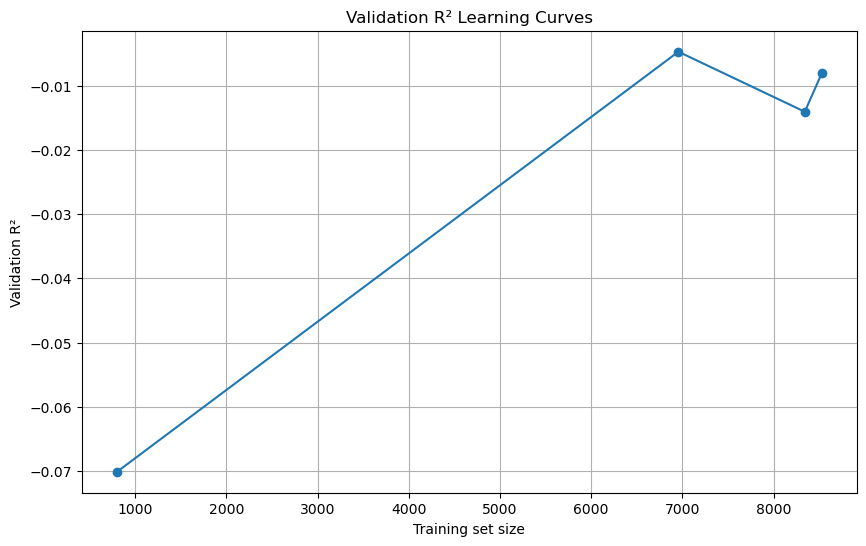

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(training_data_lens, val_R_squared, marker="o")
plt.title("Validation R² Learning Curves")
plt.xlabel("Training set size")
plt.ylabel("Validation R²")
plt.grid(True)

plt.show()

In [30]:
R2_test = models[1].score(X_test, y_test)
MSE_test = mean_squared_error(y_test, models[1].predict(X_test))

print(f"Test R2: {R2_test}, Test MSE: {MSE_test}")

Test R2: -0.028709425234779484, Test MSE: 2172.947473694711
